In [1]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if(torch.cuda.is_available()):
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [4]:
import os

print(os.getcwd())
print(os.listdir())

/content
['.config', 'sample_data']


In [6]:
#upload dataset
from google.colab import files
uploaded=files.upload()

Saving Brain_tumar_dataset.zip to Brain_tumar_dataset.zip


In [7]:
#extract the database
import zipfile
import os

zip_path="/content/Brain_tumar_dataset.zip"
extract_path="./content/brain_tumor_data"

with zipfile.ZipFile(zip_path,"r") as zip_ref:
  zip_ref.extractall(extract_path)

print("Dataset Extracted")
print(os.listdir(extract_path))

Dataset Extracted
['Testing', 'Training']


In [13]:
#get folder strucutre
import os

for root,dir,files in os.walk("./content/brain_tumor_data",""):
  level=root.replace("./content/brain_tumor_data","").count(os.sep)

  if level <=2:
    print(" " * level + os.path.basename(root)+"/")

  glioma/
  meningioma/
  pituitary/
  notumor/
 Testing/
  glioma/
  meningioma/
  pituitary/
  notumor/
 Training/
brain_tumor_data/


In [23]:
#create data loaders
import torch
from torch.utils.data import DataLoader,Subset
from torchvision import datasets,transforms

#Reproducibility
SEED=42
torch.manual_seed(SEED)

#setting
IMAGE_SIZE=224
BATCH_SIZE=32

#path
train_dir="./content/brain_tumor_data/Training"
test_dir="./content/brain_tumor_data/Testing"

#imageNet normalization
mean=[0.485,0.456,0.406]
std=[0.229,0.224,0.225]

#training transformations
train_transform=transforms.Compose([
    transforms.Resize((IMAGE_SIZE,IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ToTensor(),
    transforms.Normalize(mean,std)
])


#validation/Test transformation
eval_transform=transforms.Compose([
    transforms.Resize((IMAGE_SIZE,IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.transforms.Normalize(mean,std)
])

#load complete training data with augmentaion
train_base=datasets.ImageFolder(
    train_dir,
    transform=train_transform
)

#load the same images withouth augmentatio for validation
val_base=datasets.ImageFolder(
    train_dir,
    transform=eval_transform
)

#load test dataset
test_dataset=datasets.ImageFolder(
    test_dir,
    transform=eval_transform
)

#create reproducibe 80/20 split
generator=torch.Generator().manual_seed(SEED)

indices=torch.randperm(
    len(train_base),
    generator=generator
).tolist()

#data split
train_size=int(0.8*len(indices))

train_indices=indices[:train_size]
val_indices=indices[train_size:]

print("Number of train indices:", len(train_indices))
print("Number of validation indices:", len(val_indices))


#apply same indices to the two dataset
train_dataset=Subset(
    train_base,
    train_indices
)

val_dataset=Subset(
    val_base,
    val_indices
)

#dataloader
train_loader=DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader=DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader=DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)


print("Classes:", train_base.classes)
print("Training samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))
print("Test samples:", len(test_dataset))


Number of train indices: 4480
Number of validation indices: 1120
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Training samples: 4480
Validation samples: 1120
Test samples: 1600


BaseLine model create

In [49]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from torchvision.models import EfficientNet_B0_Weights

# Device
baseline_device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

# Load pretrained EfficientNet-B0
baseline_weights = EfficientNet_B0_Weights.DEFAULT

baseline_model = models.efficientnet_b0(
    weights=baseline_weights
)

# Freeze the entire backbone
for param in baseline_model.features.parameters():
    param.requires_grad = False

# Replace classifier for 4 classes
in_features = baseline_model.classifier[1].in_features

baseline_model.classifier = nn.Sequential(
    nn.Dropout(p=0.3),
    nn.Linear(in_features, 4)
)

# Loss
baseline_criterion = nn.CrossEntropyLoss()

# RMSProp
baseline_optimizer = optim.RMSprop(
    baseline_model.parameters(),
    lr=0.001,
    alpha=0.9,
    weight_decay=1e-4
)

# Move model to GPU
baseline_model = baseline_model.to(baseline_device)

print("Baseline EfficientNet-B0 created successfully.")
print("Device:", baseline_device)

Baseline EfficientNet-B0 created successfully.
Device: cuda


Fine tuning Efficient-B0

In [29]:
#create EfficientNet-B0 model
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from torchvision.models import EfficientNet_B0_Weights


#device select
device= torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device",device)

#load pretrained EfficientNet-B0
weights=EfficientNet_B0_Weights.DEFAULT

model=models.efficientnet_b0(weights=weights)

#fine tuning EfficientNet-B0

#freeze the backbone initially
for param in model.features.parameters():
  param.requires_grad= False

#unfreez the last 3 feature block
for param in model.features[-3:].parameters():
  param.requires_grad=True

in_features = model.classifier[1].in_features

model.classifier = nn.Sequential(
    nn.Dropout(p=0.3),
    nn.Linear(in_features, 4)
)

#keep classifier trainable
for param in model.classifier.parameters():
  param.requires_grad =True

criterion = nn.CrossEntropyLoss()

print("Loss function:", criterion)

#RMSProp optimizer
optimizer=torch.optim.RMSprop(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.001,
    alpha=0.9,
    weight_decay=1e-4
)

model = model.to(device)

print("Fine-tuning setup completed!")

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

frozen_params = sum(
    p.numel()
    for p in model.parameters()
    if not p.requires_grad
)

print("Trainable parameters:", trainable_params)
print("Frozen parameters:", frozen_params)


print("EfficientNet-B0 created successfully!")
print("Number of classes:", 4)
print("Optimizer:", type(optimizer).__name__)


Device cuda
Loss function: CrossEntropyLoss()
Fine-tuning setup completed!
Trainable parameters: 3160864
Frozen parameters: 851808
EfficientNet-B0 created successfully!
Number of classes: 4
Optimizer: RMSprop


In [30]:
for name, param in model.named_parameters():
    if param.requires_grad:
        print(name)

features.6.0.block.0.0.weight
features.6.0.block.0.1.weight
features.6.0.block.0.1.bias
features.6.0.block.1.0.weight
features.6.0.block.1.1.weight
features.6.0.block.1.1.bias
features.6.0.block.2.fc1.weight
features.6.0.block.2.fc1.bias
features.6.0.block.2.fc2.weight
features.6.0.block.2.fc2.bias
features.6.0.block.3.0.weight
features.6.0.block.3.1.weight
features.6.0.block.3.1.bias
features.6.1.block.0.0.weight
features.6.1.block.0.1.weight
features.6.1.block.0.1.bias
features.6.1.block.1.0.weight
features.6.1.block.1.1.weight
features.6.1.block.1.1.bias
features.6.1.block.2.fc1.weight
features.6.1.block.2.fc1.bias
features.6.1.block.2.fc2.weight
features.6.1.block.2.fc2.bias
features.6.1.block.3.0.weight
features.6.1.block.3.1.weight
features.6.1.block.3.1.bias
features.6.2.block.0.0.weight
features.6.2.block.0.1.weight
features.6.2.block.0.1.bias
features.6.2.block.1.0.weight
features.6.2.block.1.1.weight
features.6.2.block.1.1.bias
features.6.2.block.2.fc1.weight
features.6.2.blo

Train the V1 baseline

In [50]:
import time
import copy

NUM_EPOCHS = 25

baseline_train_losses = []
baseline_val_losses = []
baseline_train_accuracies = []
baseline_val_accuracies = []

best_baseline_val_loss = float("inf")
best_baseline_model_weights = copy.deepcopy(baseline_model.state_dict())

start_time = time.time()

for epoch in range(NUM_EPOCHS):


    # Training
    baseline_model.train()

    train_running_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:

        images = images.to(baseline_device)
        labels = labels.to(baseline_device)

        baseline_optimizer.zero_grad()

        outputs = baseline_model(images)
        loss = baseline_criterion(outputs, labels)

        loss.backward()
        baseline_optimizer.step()

        train_running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)

        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

    train_loss = train_running_loss / train_total
    train_accuracy = train_correct / train_total


    # Validation
    baseline_model.eval()

    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(baseline_device)
            labels = labels.to(baseline_device)

            outputs = baseline_model(images)
            loss = baseline_criterion(outputs, labels)

            val_running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)

            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss = val_running_loss / val_total
    val_accuracy = val_correct / val_total

    # Store history
    baseline_train_losses.append(train_loss)
    baseline_val_losses.append(val_loss)
    baseline_train_accuracies.append(train_accuracy)
    baseline_val_accuracies.append(val_accuracy)

    # Save best model based on validation loss
    if val_loss < best_baseline_val_loss:
        best_baseline_val_loss = val_loss
        best_baseline_model_weights = copy.deepcopy(
            baseline_model.state_dict()
        )

        print(
            f"Epoch {epoch+1}/{NUM_EPOCHS} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_accuracy:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_accuracy:.4f} | Best"
        )

    else:
        print(
            f"Epoch {epoch+1}/{NUM_EPOCHS} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_accuracy:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_accuracy:.4f}"
        )


training_time = time.time() - start_time

# Restore best baseline model
baseline_model.load_state_dict(best_baseline_model_weights)

print("\nBaseline training completed!")
print(f"Training time: {training_time / 60:.2f} minutes")
print(f"Best validation loss: {best_baseline_val_loss:.4f}")
print(
    f"Best validation accuracy: "
    f"{max(baseline_val_accuracies):.4f}"
)

Epoch 1/25 | Train Loss: 0.6347 | Train Acc: 0.7946 | Val Loss: 0.3948 | Val Acc: 0.8696 | Best
Epoch 2/25 | Train Loss: 0.4138 | Train Acc: 0.8545 | Val Loss: 0.3305 | Val Acc: 0.8857 | Best
Epoch 3/25 | Train Loss: 0.3781 | Train Acc: 0.8728 | Val Loss: 0.3046 | Val Acc: 0.9000 | Best
Epoch 4/25 | Train Loss: 0.3569 | Train Acc: 0.8723 | Val Loss: 0.2804 | Val Acc: 0.9036 | Best
Epoch 5/25 | Train Loss: 0.3429 | Train Acc: 0.8786 | Val Loss: 0.2731 | Val Acc: 0.9036 | Best
Epoch 6/25 | Train Loss: 0.3350 | Train Acc: 0.8846 | Val Loss: 0.2664 | Val Acc: 0.9098 | Best
Epoch 7/25 | Train Loss: 0.3246 | Train Acc: 0.8855 | Val Loss: 0.2649 | Val Acc: 0.9116 | Best
Epoch 8/25 | Train Loss: 0.3287 | Train Acc: 0.8824 | Val Loss: 0.2533 | Val Acc: 0.9125 | Best
Epoch 9/25 | Train Loss: 0.3125 | Train Acc: 0.8864 | Val Loss: 0.2484 | Val Acc: 0.9161 | Best
Epoch 10/25 | Train Loss: 0.3138 | Train Acc: 0.8830 | Val Loss: 0.2378 | Val Acc: 0.9107 | Best
Epoch 11/25 | Train Loss: 0.3048 | Trai

Train the V2 Fine tune

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [51]:
#train finetune model

import time
import copy
import torch

NUM_EPOCHS=15

best_val_loss=float("inf")
best_model_weight=copy.deepcopy(model.state_dict())

ft_train_losses = []
ft_val_losses = []
ft_train_accuracies = []
ft_val_accuracies = []

start_time=time.time()


#start train
for epoch in range(NUM_EPOCHS):
  #training
  model.train()

  running_loss=0.0
  correct=0
  total=0

  for images,labels in train_loader:
    images=images.to(device)
    labels=labels.to(device)

    optimizer.zero_grad()

    outputs=model(images)
    loss=criterion(outputs,labels)

    loss.backward()
    optimizer.step()

    running_loss+=loss.item()*images.size(0)
    _,predicted=torch.max(outputs,1)

    total+=labels.size(0)
    correct+=(predicted == labels).sum().item()

  epoch_train_loss=running_loss/total
  epoch_train_acc=correct/total


  #validate
  model.eval()

  val_running_loss=0.0
  val_corret=0
  val_total=0

  with torch.no_grad():

    for images,labels in val_loader:

      images=images.to(device)
      labels=labels.to(device)

      outputs=model(images)
      loss=criterion(outputs,labels)

      val_running_loss+=loss.item()*images.size(0)
      _,predicted=torch.max(outputs,1)

      val_total+=labels.size(0)
      val_corret+=(predicted == labels).sum().item()

  epoch_val_loss=val_running_loss/val_total
  epoch_val_acc=val_corret/val_total

  ft_train_losses.append(epoch_train_loss)
  ft_val_losses.append(epoch_val_loss)

  ft_train_accuracies.append(epoch_train_acc)
  ft_val_accuracies.append(epoch_val_acc)


  #save the  mode
  if epoch_val_loss < best_val_loss:
    best_val_loss=epoch_val_loss
    best_model_weight=copy.deepcopy(model.state_dict())

    print(
        f"Epoch {epoch + 1}/{NUM_EPOCHS} "
        f"| Train Loss: {epoch_train_loss:.4f} "
        f"| Train Acc: {epoch_train_acc:.4f} "
        f"| Val Loss: {epoch_val_loss:.4f} "
        f"| Val Acc: {epoch_val_acc:.4f} "
        f"| Best"
        )
  else:
    print(
        f"Epoch {epoch + 1}/{NUM_EPOCHS} "
        f"| Train Loss: {epoch_train_loss:.4f} "
        f"| Train Acc: {epoch_train_acc:.4f} "
        f"| Val Loss: {epoch_val_loss:.4f} "
        f"| Val Acc: {epoch_val_acc:.4f}"
    )

training_time= time.time() - start_time

#restore best model
model.load_state_dict(best_model_weight)

print("\nTraining completed!")
print(f"Training time: {training_time / 60:.2f} minutes")
print(f"Best validation loss: {best_val_loss:.4f}")
print(f"Best validation accuracy: {max(ft_val_accuracies):.4f}")


Epoch 1/15 | Train Loss: 0.0452 | Train Acc: 0.9833 | Val Loss: 0.0438 | Val Acc: 0.9884 | Best
Epoch 2/15 | Train Loss: 0.0452 | Train Acc: 0.9850 | Val Loss: 0.0756 | Val Acc: 0.9812
Epoch 3/15 | Train Loss: 0.0443 | Train Acc: 0.9873 | Val Loss: 0.1056 | Val Acc: 0.9732
Epoch 4/15 | Train Loss: 0.0442 | Train Acc: 0.9871 | Val Loss: 0.0821 | Val Acc: 0.9723
Epoch 5/15 | Train Loss: 0.0292 | Train Acc: 0.9904 | Val Loss: 0.0604 | Val Acc: 0.9857
Epoch 6/15 | Train Loss: 0.0376 | Train Acc: 0.9906 | Val Loss: 0.0726 | Val Acc: 0.9812
Epoch 7/15 | Train Loss: 0.0436 | Train Acc: 0.9864 | Val Loss: 0.0622 | Val Acc: 0.9812
Epoch 8/15 | Train Loss: 0.0351 | Train Acc: 0.9897 | Val Loss: 0.0758 | Val Acc: 0.9741
Epoch 9/15 | Train Loss: 0.0357 | Train Acc: 0.9882 | Val Loss: 0.0461 | Val Acc: 0.9848
Epoch 10/15 | Train Loss: 0.0308 | Train Acc: 0.9897 | Val Loss: 0.0564 | Val Acc: 0.9866
Epoch 11/15 | Train Loss: 0.0270 | Train Acc: 0.9911 | Val Loss: 0.0589 | Val Acc: 0.9857
Epoch 12/15 

Evaluate V1 Baseline test set

In [52]:
baseline_model.eval()

baseline_test_running_loss = 0.0
baseline_test_correct = 0
baseline_test_total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(baseline_device)
        labels = labels.to(baseline_device)

        outputs = baseline_model(images)

        loss = baseline_criterion(outputs, labels)

        baseline_test_running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)

        baseline_test_total += labels.size(0)
        baseline_test_correct += (predicted == labels).sum().item()

baseline_test_loss = (
    baseline_test_running_loss / baseline_test_total
)

baseline_test_accuracy = (
    baseline_test_correct / baseline_test_total
)

print("V1 Baseline Test Evaluation")
print("---------------------------")
print(f"Test Loss: {baseline_test_loss:.4f}")
print(f"Test Accuracy: {baseline_test_accuracy:.4f}")
print(f"Test Accuracy: {baseline_test_accuracy * 100:.2f}%")

V1 Baseline Test Evaluation
---------------------------
Test Loss: 0.5139
Test Accuracy: 0.8556
Test Accuracy: 85.56%


Finetune test set evaluation

In [53]:
#Evaluate the test set

import torch

model.eval()

test_running_loss=0.0
test_correct=0
test_total=0

with torch.no_grad():
  for images,labels in test_loader:
    images=images.to(device)
    labels=labels.to(device)

    outputs=model(images)
    loss=criterion(outputs,labels)

    test_running_loss+=loss.item()* images.size(0)
    _,predicted=torch.max(outputs,1)

    test_total+=labels.size(0)
    test_correct+=(predicted == labels).sum().item()

test_loss=test_running_loss/test_total
test_accuracy=test_correct/test_total

print("Test Evaluation")
print("----------------")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")


Test Evaluation
----------------
Test Loss: 0.3762
Test Accuracy: 0.9525
Test Accuracy: 95.25%


In [38]:
print("Test dataset size:", len(test_dataset))
print("Test classes:", test_dataset.classes)

from collections import Counter

test_labels = [label for _, label in test_dataset]

print("Test class distribution:")
print(Counter(test_labels))

Test dataset size: 1600
Test classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Test class distribution:
Counter({0: 400, 1: 400, 2: 400, 3: 400})


In [39]:
images, labels = next(iter(test_loader))

print("Labels from first test batch:")
print(labels)

print("\nUnique labels:")
print(torch.unique(labels, return_counts=True))

Labels from first test batch:
tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0])

Unique labels:
(tensor([0]), tensor([32]))


In [42]:
print("test_dataset:")
print(type(test_dataset))
print("Length:", len(test_dataset))
print("Classes:", test_dataset.classes)

print("\n-------------------------")

print("test_loader dataset:")
print(type(test_loader.dataset))
print("Length:", len(test_loader.dataset))

print("\nFirst 10 labels from test_dataset:")
print([test_dataset[i][1] for i in range(10)])

print("\nFirst 10 labels from test_loader.dataset:")
print([test_loader.dataset[i][1] for i in range(10)])

test_dataset:
<class 'torchvision.datasets.folder.ImageFolder'>
Length: 1600
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']

-------------------------
test_loader dataset:
<class 'torchvision.datasets.folder.ImageFolder'>
Length: 1600

First 10 labels from test_dataset:
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

First 10 labels from test_loader.dataset:
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [43]:
model.eval()

images, labels = next(iter(test_loader))

images = images.to(device)
labels = labels.to(device)

with torch.no_grad():
    outputs = model(images)
    predictions = torch.argmax(outputs, dim=1)

print("True labels:")
print(labels.cpu())

print("\nPredictions:")
print(predictions.cpu())

print("\nCorrect predictions:")
print((predictions == labels).sum().item(), "/", labels.size(0))

print("\nModel device:")
print(next(model.parameters()).device)

True labels:
tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0])

Predictions:
tensor([3, 0, 0, 0, 2, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 1, 0])

Correct predictions:
27 / 32

Model device:
cuda:0


V1 baseLine Classification Report + Confusion Matrix

In [54]:
from sklearn.metrics import classification_report, confusion_matrix

baseline_model.eval()

baseline_true = []
baseline_pred = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(baseline_device)

        outputs = baseline_model(images)
        predictions = torch.argmax(outputs, dim=1)

        baseline_true.extend(
            labels.cpu().numpy().tolist()
        )

        baseline_pred.extend(
            predictions.cpu().numpy().tolist()
        )

print("V1 Classification Report")
print("------------------------")

print(
    classification_report(
        baseline_true,
        baseline_pred,
        labels=[0, 1, 2, 3],
        target_names=test_dataset.classes,
        digits=4,
        zero_division=0
    )
)

print("\nV1 Confusion Matrix")
print("-------------------")

print(
    confusion_matrix(
        baseline_true,
        baseline_pred,
        labels=[0, 1, 2, 3]
    )
)

V1 Classification Report
------------------------
              precision    recall  f1-score   support

      glioma     0.9743    0.6625    0.7887       400
  meningioma     0.7764    0.8075    0.7917       400
     notumor     0.8016    1.0000    0.8899       400
   pituitary     0.9225    0.9525    0.9373       400

    accuracy                         0.8556      1600
   macro avg     0.8687    0.8556    0.8519      1600
weighted avg     0.8687    0.8556    0.8519      1600


V1 Confusion Matrix
-------------------
[[265  74  51  10]
 [  7 323  48  22]
 [  0   0 400   0]
 [  0  19   0 381]]


Classification Report and Confusion matrix

In [55]:
from sklearn.metrics import classification_report, confusion_matrix
import torch

model.eval()

all_labels = []
all_predictions = []

with torch.no_grad():
    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)
        predictions = torch.argmax(outputs, dim=1)

        # Convert each batch to Python lists
        all_labels.extend(labels.detach().cpu().numpy().tolist())
        all_predictions.extend(predictions.detach().cpu().numpy().tolist())

# Convert to tensors for verification
all_labels_tensor = torch.tensor(all_labels)
all_predictions_tensor = torch.tensor(all_predictions)

print("Total labels:", len(all_labels))
print("Total predictions:", len(all_predictions))

print("\nTrue label distribution:")
print(torch.bincount(all_labels_tensor, minlength=4))

print("\nPrediction distribution:")
print(torch.bincount(all_predictions_tensor, minlength=4))

print("\nCorrect predictions:")
print((all_labels_tensor == all_predictions_tensor).sum().item())

print("\nFull Test Accuracy:")
print(
    (all_labels_tensor == all_predictions_tensor).float().mean().item() * 100,
    "%"
)

print("\nClassification Report")
print("--------------------")

print(
    classification_report(
        all_labels,
        all_predictions,
        labels=[0, 1, 2, 3],
        target_names=test_dataset.classes,
        digits=4,
        zero_division=0
    )
)

print("\nConfusion Matrix")
print("----------------")

print(
    confusion_matrix(
        all_labels,
        all_predictions,
        labels=[0, 1, 2, 3]
    )
)

Total labels: 1600
Total predictions: 1600

True label distribution:
tensor([400, 400, 400, 400])

Prediction distribution:
tensor([338, 426, 428, 408])

Correct predictions:
1524

Full Test Accuracy:
95.24999856948853 %

Classification Report
--------------------
              precision    recall  f1-score   support

      glioma     0.9911    0.8375    0.9079       400
  meningioma     0.9131    0.9725    0.9419       400
     notumor     0.9346    1.0000    0.9662       400
   pituitary     0.9804    1.0000    0.9901       400

    accuracy                         0.9525      1600
   macro avg     0.9548    0.9525    0.9515      1600
weighted avg     0.9548    0.9525    0.9515      1600


Confusion Matrix
----------------
[[335  37  27   1]
 [  3 389   1   7]
 [  0   0 400   0]
 [  0   0   0 400]]


V1 Confusion Matrix Figure

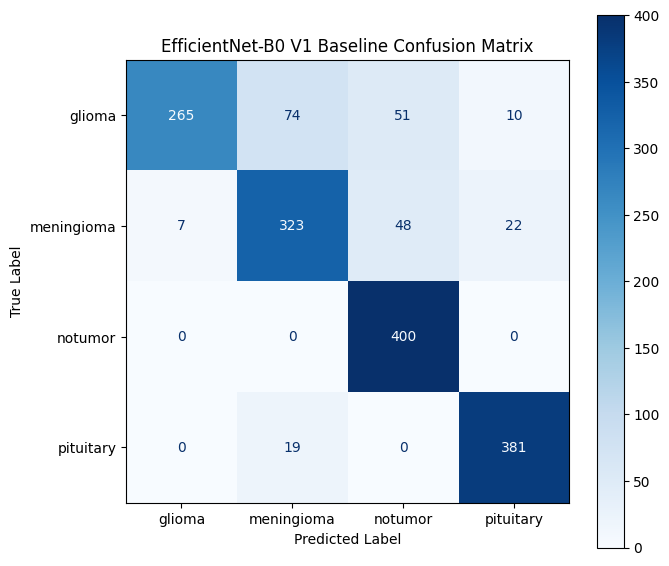

V1 confusion matrix saved successfully.


In [56]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

# Create V1 confusion matrix
baseline_cm = confusion_matrix(
    baseline_true,
    baseline_pred,
    labels=[0, 1, 2, 3]
)

fig, ax = plt.subplots(figsize=(7, 6))

display = ConfusionMatrixDisplay(
    confusion_matrix=baseline_cm,
    display_labels=test_dataset.classes
)

display.plot(
    ax=ax,
    values_format="d",
    cmap="Blues"
)

plt.title("EfficientNet-B0 V1 Baseline Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()

plt.savefig(
    "/content/EfficientNet_B0_V1_Confusion_Matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("V1 confusion matrix saved successfully.")

Fine tune Confusion Matrix Figure

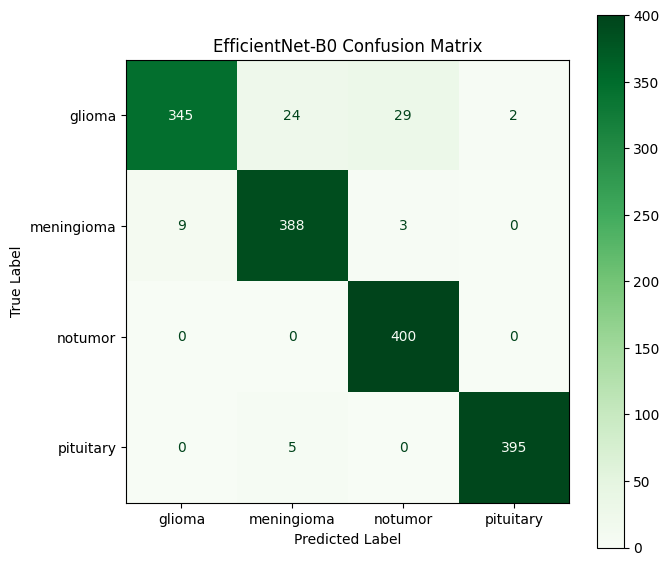

Confusion matrix saved successfully.


In [47]:
#confusion Matrix figure
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

# Create confusion matrix
cm = confusion_matrix(
    all_labels,
    all_predictions,
    labels=[0, 1, 2, 3]
)

# Create figure
fig, ax = plt.subplots(figsize=(7, 6))

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=test_dataset.classes
)

display.plot(ax=ax, values_format="d", cmap="Greens")

plt.title("EfficientNet-B0 Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()

# Save figure
plt.savefig(
    "/content/EfficientNet_B0_Confusion_Matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Confusion matrix saved successfully.")

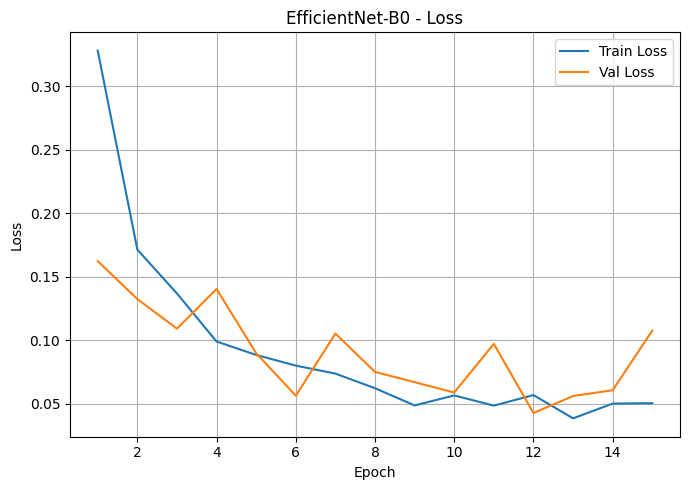

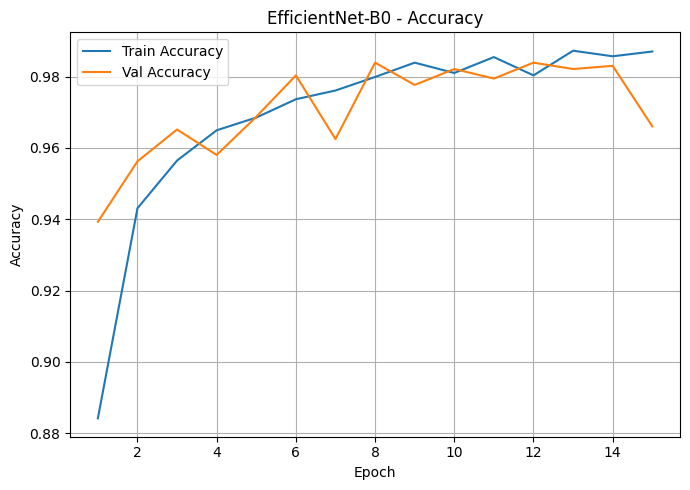

In [48]:
#learning curve
import matplotlib.pyplot as plt

epochs = range(1, len(ft_train_losses) + 1)

# Loss Curve
plt.figure(figsize=(7, 5))

plt.plot(epochs, ft_train_losses, label="Train Loss")
plt.plot(epochs, ft_val_losses, label="Val Loss")

plt.title("EfficientNet-B0 - Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig(
    "/content/EfficientNet_B0_Loss_Curve.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


# Accuracy Curve
plt.figure(figsize=(7, 5))

plt.plot(epochs, ft_train_accuracies, label="Train Accuracy")
plt.plot(epochs, ft_val_accuracies, label="Val Accuracy")

plt.title("EfficientNet-B0 - Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig(
    "/content/EfficientNet_B0_Accuracy_Curve.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()